In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('data/all_players.csv')
print(df.shape)
df.head()

(3121, 42)


,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_p90,Ast_p90,G+A_p90,G-PK_p90,G+A-PK_p90,league,team_Gls,team_Ast,pct_of_team_goals,pct_of_team_assists,Fls,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG,team_TklW,team_Int,pct_of_team_tackles,pct_of_team_interceptions
0,1,James Abankwah,ie IRL,DF,Watford,21.0,2004.0,31,30,2596,28.8,1,0,1,1,0,0,5,1,0.03,0.00,0.03,0.03,0.03,Championship,52,34,1.9,0.0,40,28,3,14,29,29,NaN,NaN,0,444,401,6.5,7.2
1,2,Ebou Adams,gm GAM,MF,Derby County,29.0,1996.0,23,16,1506,16.7,1,0,1,1,0,0,7,0,0.06,0.00,0.06,0.06,0.06,Championship,64,43,1.6,0.0,36,37,4,10,25,38,NaN,NaN,0,428,429,8.9,5.8
2,3,Ebou Adams,gm GAM,MF,Portsmouth,29.0,1996.0,16,14,1234,13.7,2,1,3,2,0,0,3,0,0.15,0.07,0.22,0.15,0.22,Championship,47,29,4.3,3.4,20,41,0,10,13,28,NaN,NaN,0,393,379,7.1,3.4
3,4,Kealey Adamson,au AUS,DF,QPR,22.0,2003.0,7,1,223,2.5,0,0,0,0,0,0,1,0,0.00,0.00,0.00,0.00,0.00,Championship,55,35,0.0,0.0,5,1,0,3,1,4,NaN,NaN,0,437,359,0.9,0.3
4,5,Tayo Adaramola,ie IRL,"MF,DF",Sheffield Weds,21.0,2003.0,16,15,1328,14.8,0,1,1,0,0,0,2,0,0.00,0.07,0.07,0.00,0.07,Championship,29,15,0.0,6.7,11,20,0,33,7,27,NaN,NaN,0,469,454,5.8,1.5


In [2]:
defenders = df[df['Pos'].str.contains('DF', na=False)].copy()
print(f"{len(defenders)} defenders out of {len(df)} total players")
defenders[['Player', 'Squad', 'league', 'Pos', 'Age', 'TklW', 'Int']].head(10)

1061 defenders out of 3121 total players


,Player,Squad,league,Pos,Age,TklW,Int
0,James Abankwah,Watford,Championship,DF,21.0,29,29
3,Kealey Adamson,QPR,Championship,DF,22.0,4,1
4,Tayo Adaramola,Sheffield Weds,Championship,"MF,DF",21.0,27,7
6,Sydney Agina,Stoke City,Championship,DF,17.0,3,3
9,Semi Ajayi,Hull City,Championship,DF,31.0,14,29
13,Ryan Alebiosu,Blackburn,Championship,"MF,DF",23.0,49,28
15,Ajibola Alese,Portsmouth,Championship,DF,24.0,0,0
18,Max Alleyne,Watford,Championship,DF,20.0,18,17
21,Olabade Aluko,Leicester City,Championship,DF,NaN,2,0
30,Ryan Andrews,Watford,Championship,"DF,MF",20.0,1,0


In [3]:
defenders[['Age', 'Min', 'TklW', 'Int', 'Fls', 'pct_of_team_tackles', 'pct_of_team_interceptions']].describe()

,Age,Min,TklW,Int,Fls,pct_of_team_tackles,pct_of_team_interceptions
count,1055.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000
mean,25.404739,1226.553252,14.065975,14.958530,14.897267,4.362205,5.270217
std,4.515016,986.367295,12.868177,14.156876,12.927001,3.560079,4.436882
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,383.000000,4.000000,4.000000,4.000000,1.400000,1.500000
50%,25.000000,1004.000000,11.000000,11.000000,12.000000,3.800000,4.300000
75%,28.000000,1971.000000,22.000000,23.000000,22.000000,6.600000,8.100000
max,40.000000,4140.000000,72.000000,80.000000,64.000000,19.000000,20.900000


## Top Defenders by raw tackles per 90


In [4]:
MIN_MINUTES = 900  # same threshold you used in forward_analysis - ~10 full matches

qualified_defenders = defenders[defenders['Min'] >= MIN_MINUTES].copy()
qualified_defenders['TklW_p90'] = (qualified_defenders['TklW'] / qualified_defenders['90s']).round(2)
qualified_defenders['Int_p90'] = (qualified_defenders['Int'] / qualified_defenders['90s']).round(2)

top_tacklers = qualified_defenders.sort_values('TklW_p90', ascending=False).reset_index(drop=True)
top_tacklers.index = top_tacklers.index + 1

top_tacklers[['Player', 'Squad', 'league', 'Age', 'Min', 'TklW', 'TklW_p90', 'Int_p90']].head(15)

,Player,Squad,league,Age,Min,TklW,TklW_p90,Int_p90
1,Timo Becker,Schalke 04,2. Bundesliga,28.0,1982,56,2.55,1.09
2,Aurélien Platret,US Boulogne,Ligue 2,22.0,1430,40,2.52,0.94
3,Jeremy Ngakia,Watford,Championship,24.0,2606,72,2.48,1.28
4,Femi Seriki,Sheffield United,Championship,23.0,2558,70,2.46,1.09
5,Brodie Spencer,Oxford United,Championship,21.0,2146,58,2.44,1.30
6,Julian Eitschberger,Hertha BSC,2. Bundesliga,21.0,1084,29,2.42,1.00
7,Giorgio Cittadini,Frosinone,Serie B,23.0,1210,32,2.39,2.39
8,DG,Avaí,Brazil Serie B,25.0,1100,29,2.38,2.13
9,Jack Currie,Oxford United,Championship,22.0,2179,57,2.36,1.69
10,Eiran Cashin,Blackburn,Championship,23.0,1543,40,2.34,1.87


## Team reliance vs defensive volume

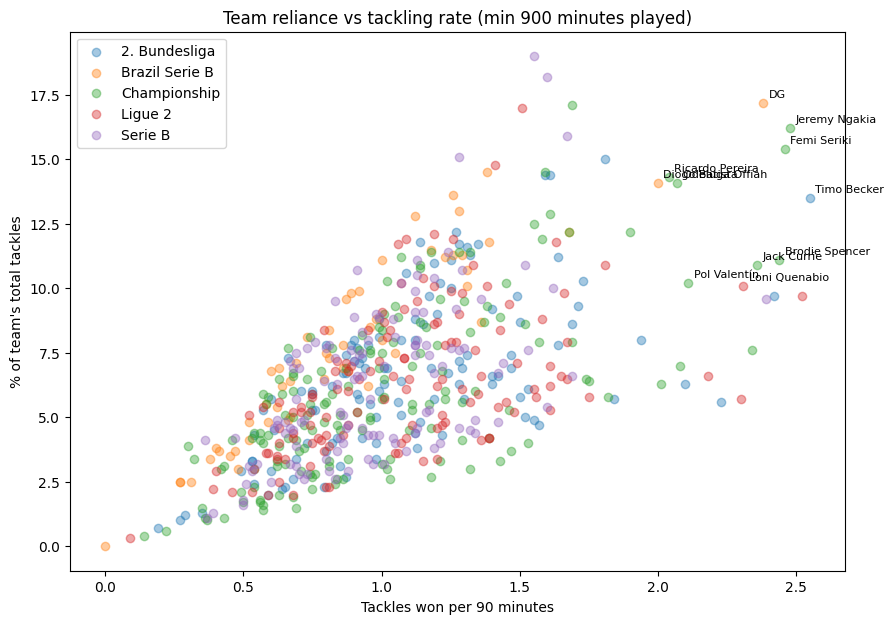

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

for league_name, group in qualified_defenders.groupby('league'):
    ax.scatter(group['TklW_p90'], group['pct_of_team_tackles'], label=league_name, alpha=0.4)

# label only genuine standouts - high on both axes - so the crowded middle
# doesn't get cluttered with text
standouts = qualified_defenders[
    (qualified_defenders['TklW_p90'] >= 2.0) &
    (qualified_defenders['pct_of_team_tackles'] >= 10)
]

for _, row in standouts.iterrows():
    ax.annotate(row['Player'], (row['TklW_p90'], row['pct_of_team_goals'] if False else row['pct_of_team_tackles']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Tackles won per 90 minutes')
ax.set_ylabel('% of team\'s total tackles')
ax.set_title('Team reliance vs tackling rate (min 900 minutes played)')
ax.legend()
plt.show()

## Young defenders with big impact

In [6]:
MAX_AGE = 23
MIN_PCT_TEAM_TACKLES = 10

young_defenders = qualified_defenders[
    (qualified_defenders['Age'] <= MAX_AGE) &
    (qualified_defenders['pct_of_team_tackles'] >= MIN_PCT_TEAM_TACKLES)
]

young_defenders_ranked = young_defenders.sort_values('pct_of_team_tackles', ascending=False).reset_index(drop=True)
young_defenders_ranked.index = young_defenders_ranked.index + 1

young_defenders_ranked[['Player', 'Squad', 'league', 'Age', 'TklW', 'TklW_p90', 'pct_of_team_tackles']].head(10)

,Player,Squad,league,Age,TklW,TklW_p90,pct_of_team_tackles
1,Stefano Di Mario,Virtus Entella,Serie B,20.0,56,1.60,18.2
2,Daniel Tonoli,Modena,Serie B,22.0,55,1.67,15.9
3,Femi Seriki,Sheffield United,Championship,23.0,70,2.46,15.4
4,Alessio Castellini,Mantova,Serie B,22.0,44,1.28,15.1
5,Mehmet Aydin,BTSV,2. Bundesliga,23.0,50,1.81,15.0
6,Berkay Yılmaz,Nürnberg,2. Bundesliga,20.0,52,1.61,14.4
7,Diogo Batista,Athletic,Brazil Serie B,22.0,23,2.00,14.1
8,Odeluga Offiah,Preston,Championship,22.0,65,2.07,14.1
9,Kellen Fisher,Norwich City,Championship,21.0,62,1.61,12.9
10,Terry Devlin,Portsmouth,Championship,21.0,48,1.68,12.2


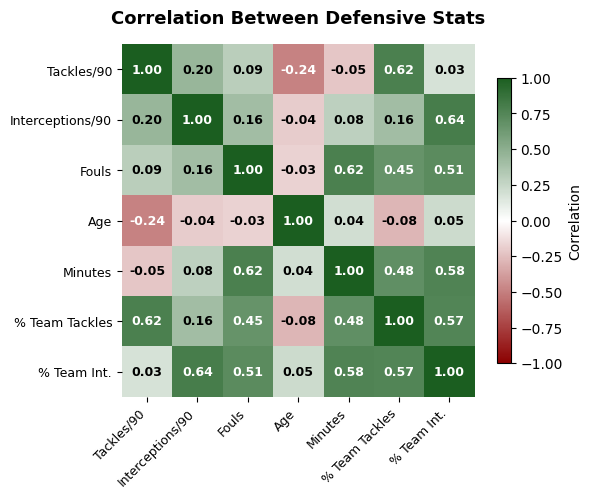

In [7]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

cols_to_correlate = ['TklW_p90', 'Int_p90', 'Fls', 'Age', 'Min',
                      'pct_of_team_tackles', 'pct_of_team_interceptions']

# short, readable labels just for display - the actual correlation still
# uses the real column names above
short_labels = ['Tackles/90', 'Interceptions/90', 'Fouls', 'Age', 'Minutes',
                '% Team Tackles', '% Team Int.']

corr_matrix = qualified_defenders[cols_to_correlate].corr().round(2)

red_green = LinearSegmentedColormap.from_list("red_green", ["#8b0000", "#ffffff", "#1b5e20"])
norm = plt.Normalize(vmin=-1, vmax=1)

def stretch(x):
    return np.sign(x) * np.abs(x) ** 0.5

color_values = corr_matrix.apply(stretch)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(color_values, cmap=red_green, vmin=-1, vmax=1)

ax.set_xticks(range(len(cols_to_correlate)))
ax.set_yticks(range(len(cols_to_correlate)))
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)

for i in range(len(cols_to_correlate)):
    for j in range(len(cols_to_correlate)):
        real_value = corr_matrix.iloc[i, j]
        stretched_value = color_values.iloc[i, j]
        r, g, b, _ = red_green(norm(stretched_value))
        brightness = 0.299 * r + 0.587 * g + 0.114 * b
        text_color = 'white' if brightness < 0.6 else 'black'
        ax.text(j, i, f"{real_value:.2f}", ha='center', va='center',
                color=text_color, fontsize=9, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Correlation')

ax.set_title('Correlation Between Defensive Stats', fontsize=13, fontweight='bold', pad=15)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

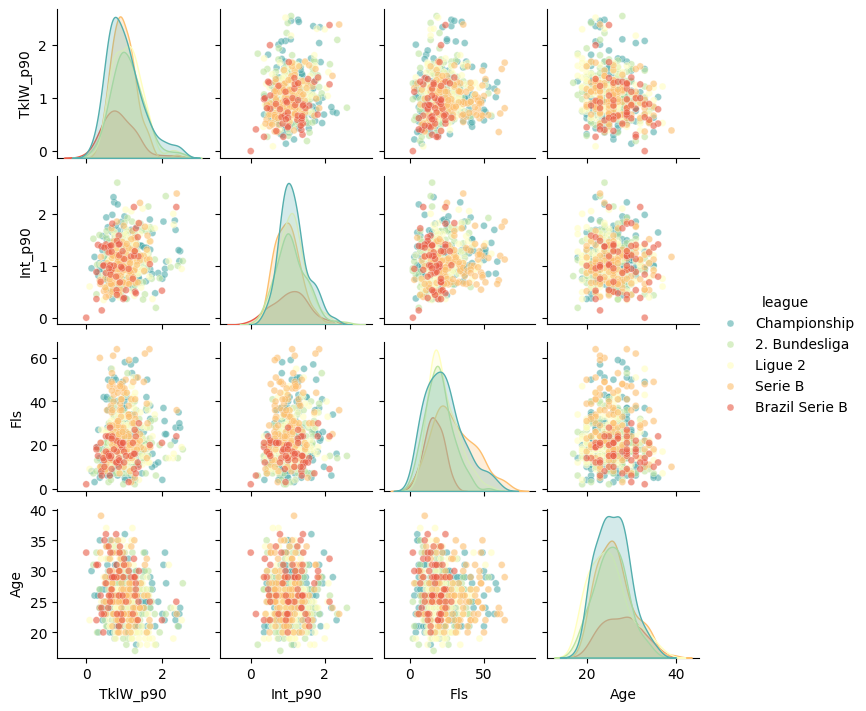

In [8]:
import seaborn as sns

pairplot_cols = ['TklW_p90', 'Int_p90', 'Fls', 'Age', 'league']

plot_data = qualified_defenders[pairplot_cols].rename(columns={'league': 'League'})

sns.pairplot(
    qualified_defenders[pairplot_cols],
    hue='league',
    palette='Spectral_r',
    plot_kws={'alpha': 0.6, 's': 25, 'edgecolor': 'white', 'linewidth': 0.3},
    diag_kind='kde',
    height=1.8,   # was the default ~2.5 - controls size of each individual small plot
)
plt.show()

## Tackle Rate Distribution by League

/var/folders/g5/_5kss0391hb12vcfrdb95x4h0000gn/T/ipykernel_95369/2707561401.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


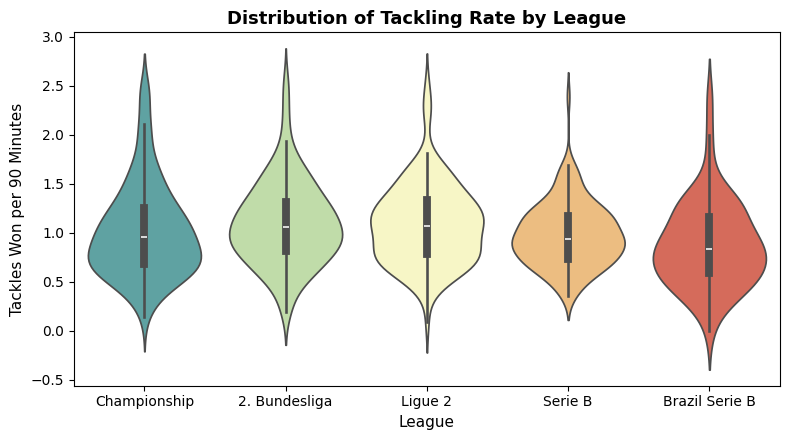

In [9]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 4.5))  # was (12, 6)

sns.violinplot(
    data=qualified_defenders,
    x='league', y='TklW_p90',
    palette='Spectral_r',
      
    ax=ax
)

ax.set_xlabel('League', fontsize=11)
ax.set_ylabel('Tackles Won per 90 Minutes', fontsize=11)
ax.set_title('Distribution of Tackling Rate by League', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()